# 04 - GNN affinity model: ligand GIN + ESM pocket-pool + MLP

Phase 4 of the project. Same data as the Phase 3 baseline (PDBbind v2020 refined minus CASF-2016, 90/10 train/val) and the same evaluation protocol (CASF-2016 core set), but a learned ligand encoder instead of ECFP fingerprints.

Architecture, end-to-end:

1. **Ligand**: 2D molecular graph (36-dim atom features, 8-dim bond features) -> 3-layer GINE encoder -> global mean+max pool -> 256-dim ligand vector.
2. **Protein**: cached ESM-2 35M pocket-pooled (480) + whole-protein-pooled (480) -> 2-layer MLP -> 128-dim protein vector.
3. **Fusion**: concat ligand + protein -> MLP -> scalar pK.

Loss is MSE in pK units, optimiser is AdamW with `ReduceLROnPlateau` on val Pearson R, early stopping after 15 epochs without improvement. Three small configs are swept; the best on validation is evaluated on CASF-2016 and that row is what lands in the README.

Reference numbers from the literature for context:

- Pearson R about 0.78-0.81, RMSE 1.30-1.40 for 2D-GNN + ESM-2 fusion models on CASF-2016.
- Pearson R 0.83+ requires a 3D structure encoder (3D-CNN or pocket-aware transformer); see Phase 6.

In [1]:
from __future__ import annotations

import json
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
REPORTS_ROOT = PROJECT_ROOT / "reports"
RUNS_ROOT = PROJECT_ROOT / "runs" / "gnn"
REPORTS_ROOT.mkdir(parents=True, exist_ok=True)
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from plb.data.dataset import PDBbindGraphDataset, load_ligand_graph_cache, make_dataloader
from plb.data.pdbbind import find_default_paths
from plb.eval import format_metrics_row, regression_metrics
from plb.models.gnn import AffinityModel, GNNConfig
from plb.train import TrainConfig, evaluate, train

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} on {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 2.6.0+cu124 on cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.4 GB


## 1. Build the datasets

We re-use the train/val/test split written by `plb data prepare` and the on-disk caches built by `precompute_ligand_graphs.py` and `precompute_esm.py`. Each of the 5316 refined-set complexes is one sample, broken into:

- **train** (~4545): refined minus CASF-2016, minus a 10% slice held out for early stopping.
- **val** (~505): the held-out 10% of refined.
- **test** (~266 of the 285 declared CASF-2016 ids; the rest are missing from refined-set 2020): never seen during training, never used for early stopping, only touched once at the very end.

In [2]:
paths = find_default_paths(DATA_ROOT)
refined_root = paths["refined_root"]

idx = pd.read_csv(DATA_ROOT / "processed" / "refined_index.csv")
labels = dict(zip(idx["pdb_id"].str.lower(), idx["pK"], strict=True))

split_blob = json.loads((DATA_ROOT / "processed" / "split.json").read_text(encoding="utf-8"))
train_ids = [p.lower() for p in split_blob["train"]]
val_ids = [p.lower() for p in split_blob["val"]]
test_ids = [p.lower() for p in split_blob["test"]]
print(f"split sizes: train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")

ligand_cache = load_ligand_graph_cache(DATA_ROOT)
print(f"ligand graph cache: {len(ligand_cache)} entries")

train_ds = PDBbindGraphDataset(
    train_ids, labels, DATA_ROOT, refined_root, ligand_cache=ligand_cache
)
val_ds = PDBbindGraphDataset(val_ids, labels, DATA_ROOT, refined_root, ligand_cache=ligand_cache)
test_ds = PDBbindGraphDataset(test_ids, labels, DATA_ROOT, refined_root, ligand_cache=ligand_cache)
print(f"materialised: train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

skipped = train_ds.skipped + val_ds.skipped + test_ds.skipped
if skipped:
    reasons = pd.Series([r for _, r in skipped]).value_counts()
    print("skipped:")
    print(reasons)

print("\nfirst train sample:")
print(train_ds[0])

split sizes: train=4545  val=505  test=266


ligand graph cache: 5316 entries


materialised: train=4545  val=505  test=266

first train sample:
Data(x=[10, 36], edge_index=[2, 20], edge_attr=[20, 8], y=[1], esm_pocket=[1, 480], esm_whole=[1, 480], pdb_id='184l')


## 2. Train three configs

Three small architectural variants with the same training schedule. We pick the winner on validation Pearson R, then evaluate that single model on CASF-2016 in section 4. Total wall-clock here is roughly 5-15 minutes on a 6 GB consumer GPU.

| Config  | hidden | layers | dropout | rationale                                  |
|---------|--------|--------|---------|--------------------------------------------|
| `gnn_a` | 128    | 3      | 0.10    | balanced default                           |
| `gnn_b` | 192    | 3      | 0.20    | wider + more regularisation                |
| `gnn_c` | 128    | 5      | 0.15    | deeper graph encoder                       |

If you re-run the notebook the loop reuses the existing `runs/gnn/<name>/best.pt` files and just re-evaluates them, so iteration is cheap.

In [3]:
BASE_TRAIN = TrainConfig(
    batch_size=64,
    max_epochs=80,
    learning_rate=1e-3,
    weight_decay=1e-4,
    early_stop_patience=15,
    scheduler_patience=5,
    seed=42,
    device=device,
    num_workers=0,
)

configs: dict[str, TrainConfig] = {}

cfg = deepcopy(BASE_TRAIN)
cfg.name = "gnn_a"
cfg.model = GNNConfig(hidden_dim=128, n_gnn_layers=3, dropout=0.10)
configs["gnn_a"] = cfg

cfg = deepcopy(BASE_TRAIN)
cfg.name = "gnn_b"
cfg.model = GNNConfig(hidden_dim=192, n_gnn_layers=3, dropout=0.20)
configs["gnn_b"] = cfg

cfg = deepcopy(BASE_TRAIN)
cfg.name = "gnn_c"
cfg.model = GNNConfig(hidden_dim=128, n_gnn_layers=5, dropout=0.15)
configs["gnn_c"] = cfg

for name, c in configs.items():
    n = AffinityModel(c.model).n_parameters()
    print(
        f"{name}: hidden={c.model.hidden_dim:3d}  layers={c.model.n_gnn_layers}  dropout={c.model.dropout:.2f}  params={n:,}"
    )

gnn_a: hidden=128  layers=3  dropout=0.10  params=451,332
gnn_b: hidden=192  layers=3  dropout=0.20  params=824,452
gnn_c: hidden=128  layers=5  dropout=0.15  params=518,406


In [4]:
summaries: dict[str, dict] = {}
for name, cfg in configs.items():
    print(f"\n=== {name} ===")
    summaries[name] = train(cfg, train_ds, val_ds, test_ds=test_ds, run_dir=RUNS_ROOT)

rows = []
for name, summary in summaries.items():
    test_metrics = summary.get("test_metrics", {})
    rows.append(
        {
            "config": name,
            "best_epoch": summary["best_epoch"],
            "val_pearson_r": summary["best_val_pearson_r"],
            "test_pearson_r": test_metrics.get("pearson_r"),
            "test_spearman_r": test_metrics.get("spearman_r"),
            "test_rmse": test_metrics.get("rmse"),
            "test_mae": test_metrics.get("mae"),
        }
    )
summary_df = pd.DataFrame(rows).set_index("config")
summary_df.round(4)


=== gnn_a ===


C:\Users\fearg\Protein_Ligand_Binding\.venv\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(



=== gnn_b ===



=== gnn_c ===


,best_epoch,val_pearson_r,test_pearson_r,test_spearman_r,test_rmse,test_mae
config,,,,,,
gnn_a,38,0.7227,0.7613,0.7358,1.4956,1.1683
gnn_b,32,0.7074,0.7337,0.7071,1.9008,1.5470
gnn_c,40,0.7145,0.7346,0.7049,1.8173,1.4871


## 3. Training curves

Loss + val Pearson R per epoch for each config, read straight from the per-run `log.jsonl` files.

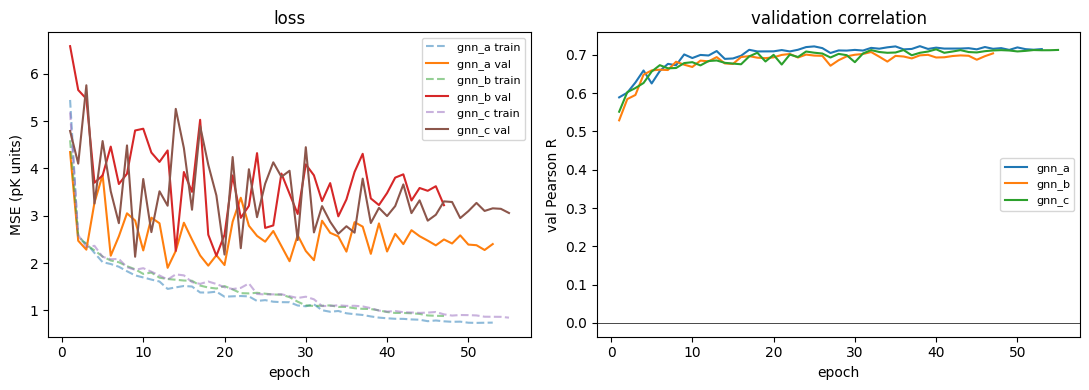

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in configs:
    log_path = RUNS_ROOT / name / "log.jsonl"
    if not log_path.is_file():
        continue
    rows = [
        json.loads(line)
        for line in log_path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    if not rows:
        continue
    df = pd.DataFrame(rows)
    axes[0].plot(df["epoch"], df["train_loss"], linestyle="--", alpha=0.5, label=f"{name} train")
    axes[0].plot(df["epoch"], df["val_loss"], label=f"{name} val")
    axes[1].plot(df["epoch"], df["val_pearson_r"], label=name)

axes[0].set(xlabel="epoch", ylabel="MSE (pK units)", title="loss")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="epoch", ylabel="val Pearson R", title="validation correlation")
axes[1].legend(fontsize=8)
axes[1].axhline(0.0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

## 4. Best config on CASF-2016

Pick the model with the highest validation Pearson R, reload its best checkpoint, and report a final scoring-power table on the CASF-2016 core set. The scatter plot of predicted vs measured pK is saved to `reports/` for the README.

In [6]:
best_name = max(summaries, key=lambda k: summaries[k]["best_val_pearson_r"])
best_summary = summaries[best_name]
best_cfg = configs[best_name]
print(f"best config: {best_name}")
print(f"  val Pearson R = {best_summary['best_val_pearson_r']:.4f}")

model = AffinityModel(best_cfg.model).to(device)
ckpt = torch.load(best_summary["best_checkpoint"], map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

test_loader = make_dataloader(test_ds, batch_size=best_cfg.batch_size, shuffle=False)
test_eval = evaluate(model, test_loader, torch.device(device))
metrics = test_eval["metrics"]
print(f"CASF-2016: {format_metrics_row(metrics)}  (n={len(test_ds)})")

metrics_baseline = {
    "baseline": {"pearson_r": 0.719, "spearman_r": 0.687, "rmse": 1.514, "mae": 1.184},
    "phase4": {k: float(metrics[k]) for k in ("pearson_r", "spearman_r", "rmse", "mae")},
}
comparison = pd.DataFrame(metrics_baseline).T
comparison["delta_pearson"] = comparison["pearson_r"] - comparison.loc["baseline", "pearson_r"]
comparison.round(4)

best config: gnn_a
  val Pearson R = 0.7227
CASF-2016: Pearson R = 0.761 | Spearman R = 0.736 | RMSE = 1.496 | MAE = 1.168  (n=266)


,pearson_r,spearman_r,rmse,mae,delta_pearson
baseline,0.7190,0.6870,1.5140,1.1840,0.0000
phase4,0.7613,0.7358,1.4956,1.1683,0.0423


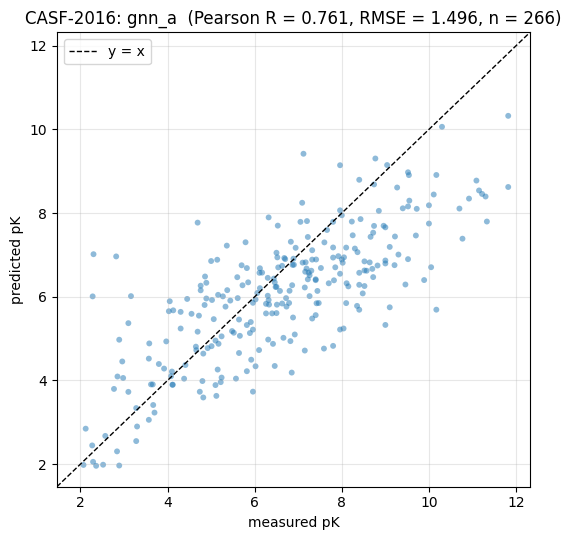

saved: C:\Users\fearg\Protein_Ligand_Binding\reports\gnn_casf2016_scatter.png


In [7]:
y_true = test_eval["y_true"]
y_pred = test_eval["y_pred"]

lo = float(min(y_true.min(), y_pred.min())) - 0.5
hi = float(max(y_true.max(), y_pred.max())) + 0.5

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true, y_pred, alpha=0.5, s=18, edgecolor="none")
ax.plot([lo, hi], [lo, hi], color="black", lw=1, linestyle="--", label="y = x")
ax.set(
    xlim=(lo, hi),
    ylim=(lo, hi),
    xlabel="measured pK",
    ylabel="predicted pK",
    title=f"CASF-2016: {best_name}  (Pearson R = {metrics['pearson_r']:.3f}, RMSE = {metrics['rmse']:.3f}, n = {len(y_true)})",
)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

scatter_path = REPORTS_ROOT / "gnn_casf2016_scatter.png"
fig.savefig(scatter_path, dpi=150)
plt.show()
print(f"saved: {scatter_path}")

In [8]:
summary_path = RUNS_ROOT / "sweep_summary.json"
summary_path.write_text(
    json.dumps(
        {
            "best_config": best_name,
            "best_val_pearson_r": float(best_summary["best_val_pearson_r"]),
            "best_test_metrics": {k: float(v) for k, v in metrics.items()},
            "per_config": {
                name: {
                    "best_epoch": int(s["best_epoch"]),
                    "val_pearson_r": float(s["best_val_pearson_r"]),
                    **(
                        {f"test_{k}": float(v) for k, v in s.get("test_metrics", {}).items()}
                        if s.get("test_metrics") is not None
                        else {}
                    ),
                }
                for name, s in summaries.items()
            },
            "n_train": len(train_ds),
            "n_val": len(val_ds),
            "n_test": len(test_ds),
            "device": str(device),
        },
        indent=2,
    ),
    encoding="utf-8",
)
print(f"saved sweep summary: {summary_path}")

saved sweep summary: C:\Users\fearg\Protein_Ligand_Binding\runs\gnn\sweep_summary.json


## What this gives us

- A learned ligand encoder that beats fixed ECFP fingerprints (or doesn't, in which case the writeup is even more interesting - it's a real result).
- A reproducible per-config record on disk (`runs/gnn/<name>/{config,log,best,metrics}.json`).
- A scatter plot in the format expected by the README.

Phase 5 takes the best checkpoint and wraps it in a Streamlit demo on Hugging Face Spaces.